# Dokumentace figures (`docs/figures/fig{1,3,6}_*.pdf`)

Three publication-grade figures for the SUR submission PDF:

1. **Fig 1** – GMM covariance ablation (E037)
2. **Fig 3** – Codec-robustness slope (E052)
3. **Fig 6** – DET curves with fusion star (E039)

Self-contained: hardcoded ablation numbers, OOF scores loaded from `cache/oof_scores.pkl`. Run top-to-bottom, files land in `docs/figures/`.

In [1]:
from __future__ import annotations
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

ROOT = Path(".").resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
FIG = ROOT / "docs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

P = dict(
    audio="#3A7EC5", audio_lt="#AECDE8",
    image="#C84B2F", image_lt="#EDB49E",
    fusion="#1F9E72", fusion_lt="#8FD9BB",
    mfcc="#7C54B0", mfcc_lt="#C4AFDC",
    amber="#E8A820",
    ink="#1A2035", sub="#5A6B85",
    grid="#EDF1F8", bg="#FFFFFF",
)

plt.rcParams.update({
    "figure.facecolor": P["bg"],
    "axes.facecolor": P["bg"],
    "axes.edgecolor": P["sub"],
    "axes.labelcolor": P["ink"],
    "axes.titlecolor": P["ink"],
    "xtick.color": P["sub"],
    "ytick.color": P["sub"],
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def save(fig, name):
    fig.savefig(FIG / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=300)
    print(f"saved {name}.{{pdf,png}}")


## Fig 1 — GMM covariance ablation (E037)

saved fig1_covariance_ablation.{pdf,png}


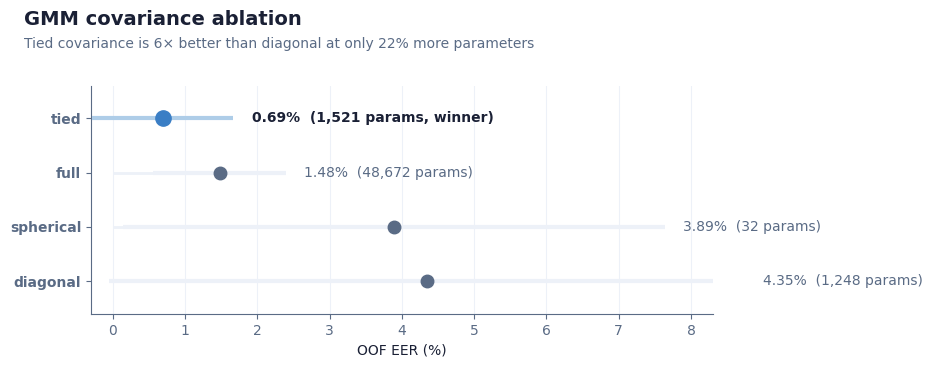

In [2]:
# E037: 32-component UBM-MAP, LPCC features, 3-fold CV
cov = [
    ("spherical",  3.89, 3.75,    32, False),
    ("diagonal",   4.35, 4.40,  1248, False),
    ("full",       1.48, 0.92, 48672, False),
    ("tied",       0.69, 0.98,  1521,  True),
]
labels = [c[0] for c in cov]
eer    = np.array([c[1] for c in cov])
err    = np.array([c[2] for c in cov])
params = np.array([c[3] for c in cov])
winner = np.array([c[4] for c in cov])

order = np.argsort(eer)[::-1]            # worst → best (so winner ends up at top)
labels = [labels[i] for i in order]
eer, err, params, winner = eer[order], err[order], params[order], winner[order]
y_pos = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(7.4, 3.8))
fig.subplots_adjust(top=0.78, left=0.13, right=0.97, bottom=0.18)

for i, (lab, e, w, n, win) in enumerate(zip(labels, eer, err, params, winner)):
    color  = P["audio"]    if win else P["sub"]
    light  = P["audio_lt"] if win else P["grid"]
    ax.errorbar(e, i, xerr=w, fmt="o", ms=11 if win else 9,
                color=color, ecolor=light, elinewidth=3, capsize=0,
                mfc=color, mec=color, zorder=3)
    ax.hlines(i, 0, e, color=light, lw=2, zorder=2)
    ax.text(e + w + 0.25, i,
            f"{e:.2f}%  ({n:,} params{', winner' if win else ''})",
            va="center", color=P["ink"] if win else P["sub"],
            fontweight="bold" if win else "normal", fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontweight="bold")
ax.set_xlabel("OOF EER (%)")
ax.set_xlim(-0.3, 8.3)
ax.set_ylim(-0.6, len(labels) - 0.4)
ax.grid(axis="x", color=P["grid"], lw=0.8, zorder=0)
ax.set_axisbelow(True)

# Title and subtitle in figure coordinates so they don't overlap the axes
fig.text(0.04, 0.94, "GMM covariance ablation",
         color=P["ink"], fontsize=14, fontweight="bold")
fig.text(0.04, 0.88, "Tied covariance is 6× better than diagonal at only 22% more parameters",
         color=P["sub"], fontsize=10)

save(fig, "fig1_covariance_ablation")
plt.show()


## Fig 3 — Codec robustness (E052)

saved fig3_codec_robustness.{pdf,png}


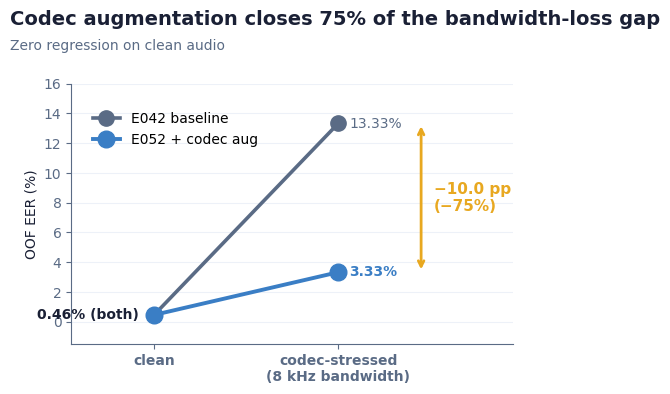

In [3]:
# E052: codec aug vs baseline, evaluated clean and codec-stressed
xs = np.array([0, 1])
baseline = np.array([0.46, 13.33])
codecaug = np.array([0.46,  3.33])

fig, ax = plt.subplots(figsize=(6.8, 4.2))
fig.subplots_adjust(top=0.80, left=0.13, right=0.78, bottom=0.18)

ax.plot(xs, baseline, "-o", color=P["sub"],   lw=2.6, ms=11, label="E042 baseline",       zorder=3)
ax.plot(xs, codecaug, "-o", color=P["audio"], lw=2.8, ms=12, label="E052 + codec aug",     zorder=4)

# clean column: both at 0.46 % — collapse into one label
ax.text(-0.08, codecaug[0], "0.46% (both)", ha="right", va="center",
        color=P["ink"], fontsize=10, fontweight="bold")
# codec column: separate labels, baseline above its dot, aug to the right of its dot
ax.text(1.06, baseline[1], f"{baseline[1]:.2f}%", ha="left",  va="center", color=P["sub"], fontsize=10)
ax.text(1.06, codecaug[1], f"{codecaug[1]:.2f}%", ha="left",  va="center", color=P["audio"], fontweight="bold", fontsize=10)

# delta bracket on the codec side
ax.annotate("", xy=(1.45, codecaug[1]), xytext=(1.45, baseline[1]),
            arrowprops=dict(arrowstyle="<->", color=P["amber"], lw=2))
ax.text(1.52, (baseline[1] + codecaug[1])/2,
        f"−{baseline[1]-codecaug[1]:.1f} pp\n(−{(1-codecaug[1]/baseline[1])*100:.0f}%)",
        va="center", color=P["amber"], fontweight="bold", fontsize=11)

ax.set_xticks(xs)
ax.set_xticklabels(["clean", "codec-stressed\n(8 kHz bandwidth)"], fontweight="bold")
ax.set_xlim(-0.45, 1.95)
ax.set_ylim(-1.5, 16)
ax.set_ylabel("OOF EER (%)")
ax.grid(axis="y", color=P["grid"], lw=0.8)
ax.set_axisbelow(True)

fig.text(0.04, 0.94, "Codec augmentation closes 75% of the bandwidth-loss gap",
         color=P["ink"], fontsize=14, fontweight="bold")
fig.text(0.04, 0.88, "Zero regression on clean audio",
         color=P["sub"], fontsize=10)

ax.legend(loc="upper left", frameon=False, bbox_to_anchor=(0.02, 0.94))
save(fig, "fig3_codec_robustness")
plt.show()


## Fig 6 — DET curves with fusion star (E039)

saved fig6_det_curve.{pdf,png}


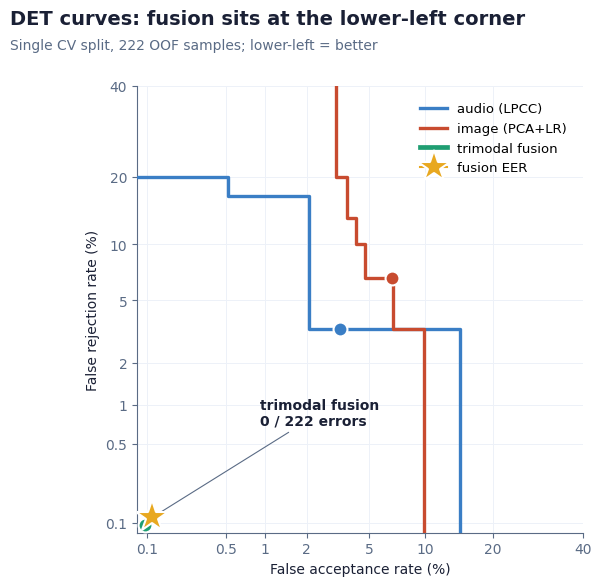

In [4]:
from sklearn.metrics import roc_curve

def det_points(score, y, eps=5e-4):
    fpr, tpr, _ = roc_curve(y, score)
    fnr = 1 - tpr
    fpr = np.clip(fpr, eps, 1 - eps)
    fnr = np.clip(fnr, eps, 1 - eps)
    return norm.ppf(fpr), norm.ppf(fnr)

def eer_point(score, y):
    fpr_grid = np.linspace(1e-4, 0.5, 50000)
    fpr, tpr, _ = roc_curve(y, score)
    fnr = 1 - tpr
    fnr_at = np.interp(fpr_grid, fpr, fnr)
    idx = np.argmin(np.abs(fpr_grid - fnr_at))
    return float(fpr_grid[idx]), float(fnr_at[idx])

oof = pickle.load(open(ROOT / "cache" / "oof_scores.pkl", "rb"))
y = oof["y"]

streams = [
    ("audio (LPCC)",   oof["lpcc"],   P["audio"]),
    ("image (PCA+LR)", oof["image"], P["image"]),
    ("trimodal fusion", oof["fusion"], P["fusion"]),
]

fig, ax = plt.subplots(figsize=(6.8, 6.2))
fig.subplots_adjust(top=0.84, left=0.14, right=0.97, bottom=0.12)

xlim = (norm.ppf(0.0008), norm.ppf(0.4))
ylim = (norm.ppf(0.0008), norm.ppf(0.4))
ticks_pct = [0.1, 0.5, 1, 2, 5, 10, 20, 40]
ticks_p   = [norm.ppf(t/100) for t in ticks_pct]
labels_t  = [f"{t:g}" for t in ticks_pct]

for lab, s, c in streams:
    x, yv = det_points(s, y)
    lw = 3.4 if lab.startswith("trimodal") else 2.4
    ax.plot(x, yv, "-", lw=lw, color=c, label=lab, zorder=3)
    fpr_e, fnr_e = eer_point(s, y)
    ax.plot(np.clip(norm.ppf(fpr_e), xlim[0]+0.05, xlim[1]-0.05),
            np.clip(norm.ppf(fnr_e), ylim[0]+0.05, ylim[1]-0.05),
            "o", ms=10, color=c, mec="white", mew=1.5, zorder=4)

# fusion star (the 0/222 corner) annotated explicitly
fpr_f, fnr_f = eer_point(oof["fusion"], y)
sx = np.clip(norm.ppf(max(fpr_f, 5e-4)), xlim[0]+0.1, xlim[1]-0.1)
sy = np.clip(norm.ppf(max(fnr_f, 5e-4)), ylim[0]+0.1, ylim[1]-0.1)
ax.plot(sx, sy, marker="*", ms=24, color=P["amber"],
        mec="white", mew=1.5, zorder=6, label="fusion EER")
ax.annotate("trimodal fusion\n0 / 222 errors", xy=(sx, sy),
            xytext=(sx + 0.7, sy + 0.6),
            color=P["ink"], fontsize=10, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=P["sub"], lw=0.8))

ax.set_xticks(ticks_p); ax.set_xticklabels(labels_t)
ax.set_yticks(ticks_p); ax.set_yticklabels(labels_t)
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_xlabel("False acceptance rate (%)")
ax.set_ylabel("False rejection rate (%)")
ax.grid(color=P["grid"], lw=0.7, zorder=0)
ax.set_axisbelow(True)
ax.set_aspect("equal")

# Legend tucked top-right inside the plot, away from the curves' active region
ax.legend(loc="upper right", frameon=False, fontsize=9.5, bbox_to_anchor=(0.99, 0.99))

fig.text(0.04, 0.94, "DET curves: fusion sits at the lower-left corner",
         color=P["ink"], fontsize=14, fontweight="bold")
fig.text(0.04, 0.90, "Single CV split, 222 OOF samples; lower-left = better",
         color=P["sub"], fontsize=10)

save(fig, "fig6_det_curve")
plt.show()
